# New Zealand earthquakes, 2000–2026

**Questions:** where do New Zealand's earthquakes happen, how often does each size come, how quickly do aftershocks fade, and can the catalogue be trusted as it stands?

**Data:** every event of magnitude 2.5+ that GeoNet recorded from January 2000 to October 2026, downloaded from its FDSN event service by `pipeline/fetch.py` (one gzipped file per year).

**Method:** the raw files are loaded, typed and de-duplicated in DuckDB with the SQL in `../sql`. The statistical parts (declustering, the b-value, aftershock fits) are imported from `pipeline/build.py`, so this notebook runs exactly the code behind the dashboard.

In [1]:
import json, os, sys
from pathlib import Path
import duckdb, numpy as np, pandas as pd, matplotlib.pyplot as plt

ROOT = Path.cwd().parent
os.chdir(ROOT)                                  # the SQL reads data/raw/... relative to the project root
sys.path.insert(0, str(ROOT / "pipeline"))
from build import decluster, b_value, omori_fit, cross_section, city_table, SEQUENCES, MODERN

con = duckdb.connect()
for f in sorted(Path("sql").glob("*.sql")):
    con.execute(f.read_text())
q = lambda sql: con.execute(sql).df()

plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .3, "font.size": 10})
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#8a8a8a"
DEPTH_BINS, DEPTH_COLORS = [0, 40, 100, 200, 1000], ["#b7d3f6", "#6da7ec", "#2a78d6", "#184f95"]

## 1. Data profile and quality checks

In [2]:
q("""SELECT count(*) AS events, count(DISTINCT event_id) AS unique_ids,
          min(origin_utc) AS first, max(origin_utc) AS last FROM events""")

,events,unique_ids,first,last
0,204774,204774,2000-01-01 04:29:06,2026-10-02 23:22:15


**Request limits.** GeoNet's service refuses requests of more than 10,000 events with an error page instead of data, so the busiest years (2009–2011 and 2016) had to be fetched in halves. A failed year would show up as a file with almost no rows, or an error message where the header should be.

In [3]:
per_year = q("SELECT year(origin_utc) AS yr, count(*) AS events FROM events GROUP BY 1 ORDER BY 1")
assert per_year["events"].min() > 4000, "a year looks truncated"
assert q("SELECT count(*) AS n FROM events_raw WHERE eventid LIKE 'Error%'")["n"][0] == 0
per_year.set_index("yr").T

yr,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
events,6160,8056,5426,9401,7527,8060,7575,9089,8474,10668,...,6594,4454,6057,5879,9030,5435,5574,5795,5733,4690


**Not everything is an earthquake.** The catalogue also holds quarry blasts, landslides, avalanches, events far outside New Zealand, and one nuclear test. The analysis keeps events typed `earthquake`, plus `unknown` (many 2012–2018 events were never given a type) and `volcano-tectonic`, inside 34–48°S and 165–180°E.

In [4]:
q("SELECT * FROM event_types")

,event_type,events,largest_place,largest_mag,largest_date
0,earthquake,169702,610 km south-west of Snares Islands,8.1,2004-12-23
1,outside of network interest,16903,10840 km east of Te Araroa,8.3,2017-09-08
2,unknown,14307,1970 km north of Cape Reinga,6.3,2015-01-23
3,other,2999,8930 km south-east of Dunedin,8.8,2010-02-27
4,quarry blast,554,25 km north-west of Palmerston,3.6,2017-01-22
5,not locatable,225,10780 km north-west of Cape Reinga,7.4,2026-08-18
6,volcano-tectonic,65,15 km north of Opunake,4.2,2026-09-05
7,snow avalanche,8,10 km north-east of Fairlie,3.1,2000-12-27
8,landslide,6,10 km north-east of Mount Cook,3.2,2020-02-01
9,volcanic eruption,2,1930 km north-east of Cape Reinga,5.6,2022-01-15


In [5]:
q("""SELECT count(*) AS in_study FROM nz_quakes""")

,in_study
0,175390


## 2. The 2012 magnitude change

Before using rates over time, check that a magnitude means the same thing in every year. Event IDs change format on 1 January 2012, from numbers to IDs like `2012p…`, which marks GeoNet's move to its SeisComP processing system.

In [6]:
q("""SELECT year(origin_utc) AS yr,
          count(*) FILTER (WHERE event_id LIKE '20%p%') AS new_style_ids,
          count(*) FILTER (WHERE event_id NOT LIKE '%p%') AS old_style_ids
   FROM events WHERE year(origin_utc) BETWEEN 2010 AND 2013 GROUP BY 1 ORDER BY 1""")

,yr,new_style_ids,old_style_ids
0,2010,0,12420
1,2011,0,13146
2,2012,7110,0
3,2013,7407,0


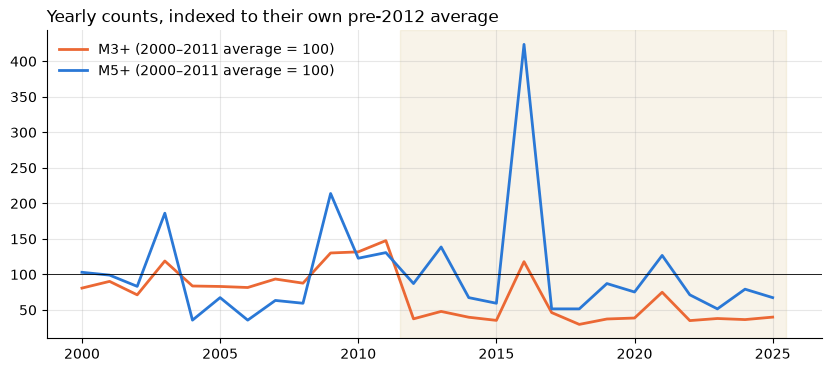

,threshold,per_year_before,per_year_after,ratio
0,2.5,8390.166667,5125.285714,1.64
1,3.0,4083.750000,1908.428571,2.14
2,3.5,1491.333333,703.142857,2.12
3,4.0,423.916667,251.500000,1.69
4,4.5,108.750000,85.000000,1.28
5,5.0,25.250000,25.928571,0.97
6,5.5,5.583333,7.500000,0.74
7,6.0,1.333333,2.000000,0.67


In [7]:
ann = q("SELECT * FROM annual_counts WHERE yr <= 2025")
fig, ax = plt.subplots()
for col, c, lab in [("m3", ORANGE, "M3+"), ("m5", BLUE, "M5+")]:
    base = ann.loc[ann["yr"] <= 2011, col].mean()
    ax.plot(ann["yr"], 100 * ann[col] / base, color=c, lw=2, label=f"{lab} (2000–2011 average = 100)")
ax.axvspan(2011.5, 2025.5, color="#c9a04c", alpha=.12)
ax.axhline(100, color="k", lw=.6); ax.legend(frameon=False)
ax.set_title("Yearly counts, indexed to their own pre-2012 average", loc="left")
plt.show()
sc = q("SELECT * FROM scale_change")
sc["ratio"] = (sc["per_year_before"] / sc["per_year_after"]).round(2)
sc

**Result:** M3+ counts halved in 2012 and stayed down outside the big sequences, while M5+ counts didn't move. Real seismicity can't change by size like that overnight; the way small magnitudes are calculated did. Matching yearly rates gives an approximate translation from old to modern magnitudes:

In [8]:
fm = q("SELECT m, per_year_at_least FROM freq_mag ORDER BY m")
equiv = [(m, np.interp(-np.log10(r), -np.log10(fm["per_year_at_least"]), fm["m"]))
         for m, r in zip(sc["threshold"], sc["per_year_before"]) if m <= 5]
pd.DataFrame(equiv, columns=["old magnitude", "modern equivalent"]).round(2)

,old magnitude,modern equivalent
0,2.5,2.50
1,3.0,2.65
2,3.5,3.12
3,4.0,3.76
4,4.5,4.38
5,5.0,5.01


In [9]:
ratio = sc.set_index("threshold")["ratio"]
assert ratio[3.0] > 1.8 and 0.85 < ratio[5.0] < 1.15, "the scale-change pattern has shifted; recheck"
print("Decision: rates, the b-value and declustering use", MODERN, "only.")

Decision: rates, the b-value and declustering use (2012, 2025) only.


## 3. Where they strike, and how deep

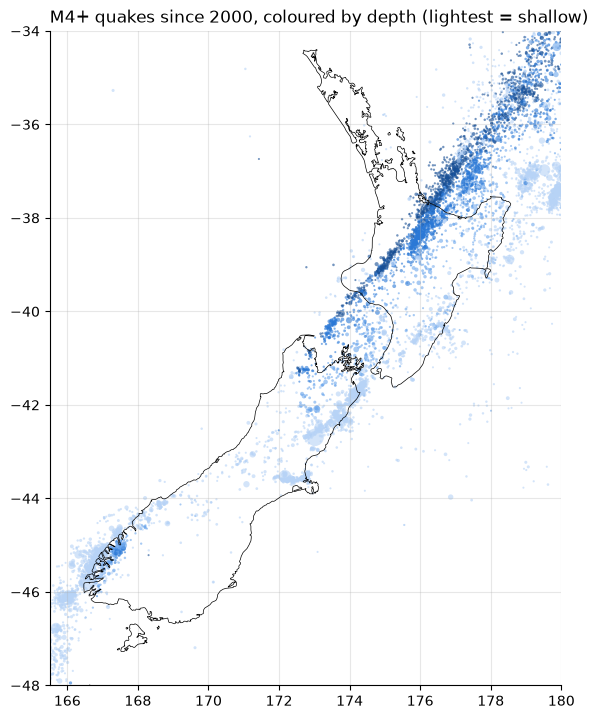

,depth_band,events,pct
0,Shallow (<40 km),18176,68.0
1,100–200 km,3971,14.9
2,200 km +,2303,8.6
3,40–100 km,2268,8.5


In [10]:
df = q("SELECT * FROM nz_quakes ORDER BY origin_utc")
m4 = df[df["mag"] >= 4].sort_values("mag")
colors = pd.cut(m4["depth_km"], DEPTH_BINS, right=False, labels=DEPTH_COLORS).astype(str)
fig, ax = plt.subplots(figsize=(7, 8.5))
ax.scatter(m4["lon"], m4["lat"], s=(1.5 * 1.75 ** (m4["mag"] - 4)) ** 2, c=colors, alpha=.6, linewidths=0)
coast = json.loads(Path("data/raw/nz-coastline.json").read_text())
for ring in coast:
    xs, ys = zip(*ring); ax.plot(xs, ys, color="k", lw=.5)
ax.set_aspect(1 / np.cos(np.radians(41))); ax.set_xlim(165.5, 180); ax.set_ylim(-48, -34)
ax.set_title("M4+ quakes since 2000, coloured by depth (lightest = shallow)", loc="left")
plt.show()
q("SELECT * FROM depth_bands ORDER BY events DESC")

A cross-section along a line running west-north-west from the Hikurangi trench, keeping quakes within 50 km of it, shows the subducting Pacific plate.

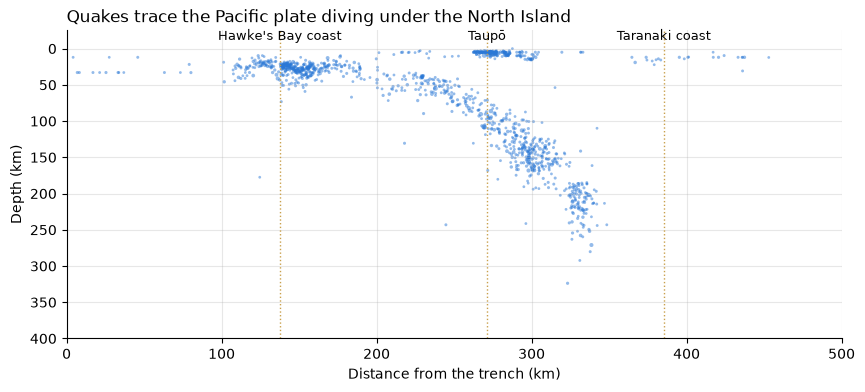

In [11]:
sec = cross_section(df[df["yr"].between(*MODERN)])
pts = np.array(sec["points"])
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(pts[:, 0], pts[:, 1], s=4 * 1.6 ** (pts[:, 2] - 3), color=BLUE, alpha=.5, linewidths=0)
for m in sec["marks"]:
    ax.axvline(m["along"], color="#c9a04c", ls=":", lw=1); ax.text(m["along"], -12, m["name"], ha="center", fontsize=9)
ax.set_ylim(400, -25); ax.set_xlim(0, 500)
ax.set_xlabel("Distance from the trench (km)"); ax.set_ylabel("Depth (km)")
ax.set_title("Quakes trace the Pacific plate diving under the North Island", loc="left")
plt.show()

## 4. How often each size comes: the b-value

The Gutenberg–Richter law says the number of quakes at or above magnitude M falls as log₁₀ N = a − bM. The b-value is estimated by maximum likelihood (Aki 1965, with Utsu's correction for 0.1-unit bins) above a completeness magnitude Mc. The estimate should be stable if Mc is chosen well.

In [12]:
mags = df.loc[df["yr"].between(*MODERN), "mag"].to_numpy()
stab = pd.DataFrame({"Mc": np.arange(2.6, 4.01, 0.2).round(1)})
stab["b"] = [b_value(mags, m) for m in stab["Mc"]]
stab["n"] = [(mags >= m - 1e-9).sum() for m in stab["Mc"]]
rng = np.random.default_rng(7)
above = mags[mags >= 3.0 - 1e-9]
boot = np.array([b_value(rng.choice(above, len(above)), 3.0) for _ in range(500)])
b = b_value(mags, 3.0)
print(f"b = {b:.3f} at Mc = 3.0, 95% bootstrap interval {np.percentile(boot, 2.5):.3f}–{np.percentile(boot, 97.5):.3f}")
print(f"Each whole magnitude is about {10 ** b:.1f} times rarer.")
stab.round(3)

b = 0.880 at Mc = 3.0, 95% bootstrap interval 0.869–0.890
Each whole magnitude is about 7.6 times rarer.


,Mc,b,n
0,2.6,0.924,64650
1,2.8,0.905,41510
2,3.0,0.880,26718
3,3.2,0.894,18033
4,3.4,0.906,12051
5,3.6,0.934,8137
6,3.8,0.967,5431
7,4.0,0.985,3521


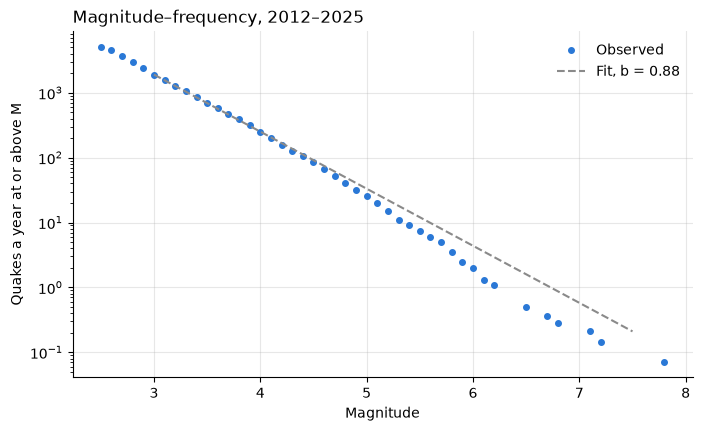

,m,per_year_at_least
5,3.0,1908.43
15,4.0,251.50
25,5.0,25.93
35,6.0,2.00


In [13]:
years = MODERN[1] - MODERN[0] + 1
fmq = q("SELECT * FROM freq_mag")
a = np.log10(len(above) / years) + b * 3.0
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(fmq["m"], fmq["per_year_at_least"], "o", color=BLUE, ms=4, label="Observed")
mm = np.linspace(3, 7.5, 50)
ax.semilogy(mm, 10 ** (a - b * mm), "--", color=GREY, label=f"Fit, b = {b:.2f}")
ax.set_xlabel("Magnitude"); ax.set_ylabel("Quakes a year at or above M"); ax.legend(frameon=False)
ax.set_title(f"Magnitude–frequency, {MODERN[0]}–{MODERN[1]}", loc="left")
plt.show()
fmq[fmq["m"].isin([3.0, 4.0, 5.0, 6.0, 7.0])][["m", "per_year_at_least"]].round(2)

**Result:** b ≈ 0.88 and stable between Mc 2.6 and 3.6 (0.88–0.93). It drifts up above M3.6 as the sample thins. Below M3 the observed counts sit slightly under the line: the network misses some small quakes.

## 5. How aftershocks fade: the Omori law

Aftershock rates decay as n(t) = K / (c + t)^p. Each sequence is fitted by maximum likelihood to M3.5+ events inside a box around the rupture. The first 1.2 hours are left out because small aftershocks are missed while the mainshock is still shaking. Darfield stops at 170 days, before the separate Christchurch earthquake of 22 February 2011.

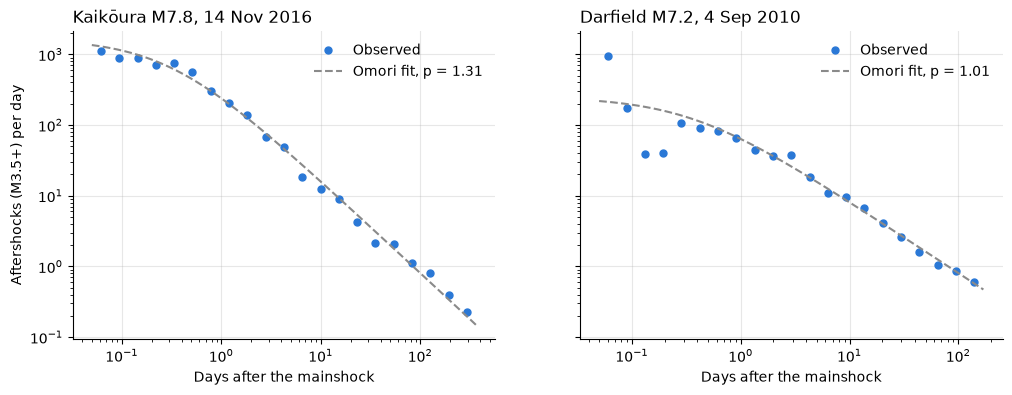

,name,mag,n,mmin,K,c,p,day1,after30,days,day30_vs_day1
kaikoura,"Kaikōura M7.8, 14 Nov 2016",7.8,1331,3.5,334.4,0.294,1.31,522,222,365,62
darfield,"Darfield M7.2, 4 Sep 2010",7.2,506,3.5,85.9,0.348,1.01,95,136,170,23


In [14]:
fits = {k: omori_fit(df, s) for k, s in SEQUENCES.items()}
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (k, f) in zip(axes, fits.items()):
    o, ft = pd.DataFrame(f["obs"]), pd.DataFrame(f["fit"])
    ax.loglog(o["t"], o["rate"], "o", color=BLUE, ms=5, label="Observed")
    ax.loglog(ft["t"], ft["rate"], "--", color=GREY, label=f"Omori fit, p = {f['p']:.2f}")
    ax.set_title(f["name"], loc="left"); ax.set_xlabel("Days after the mainshock"); ax.legend(frameon=False)
axes[0].set_ylabel("Aftershocks (M3.5+) per day")
plt.show()
summary = pd.DataFrame({k: {kk: v for kk, v in f.items() if kk not in ("obs", "fit")} for k, f in fits.items()}).T
summary["day30_vs_day1"] = [round(((f["c"] + 30) / (f["c"] + 1)) ** f["p"]) for f in fits.values()]
summary

**Result:** Kaikōura decayed fast (p = 1.31): a month after the mainshock its daily rate was about 1/62 of the rate a day after. Darfield followed the textbook p ≈ 1.

## 6. Removing the aftershocks

Gardner–Knopoff (1974) declustering works down from the largest quake: any smaller quake inside its magnitude-dependent space–time window counts as a dependent (aftershock or foreshock). Applied to M3+ quakes since 2012.

27,933 quakes, 23.6% mainshocks


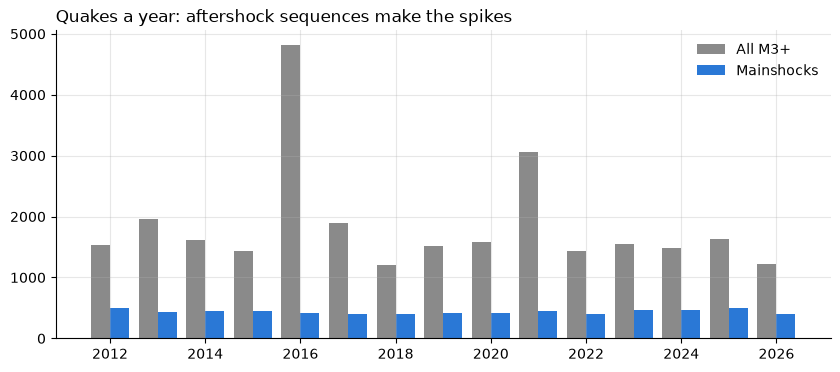

Mainshocks per full year: 395–501 (coefficient of variation 7.3%)


yr,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
all_events,1530,1956,1622,1442,4816,1890,1211,1521,1577,3059,1429,1549,1487,1629,1215
mainshocks,501,433,448,442,424,408,395,420,422,456,408,465,474,492,399


In [15]:
mod = df[(df["yr"] >= MODERN[0]) & (df["mag"] >= 3)].reset_index(drop=True)
mod["is_main"] = decluster(mod)
yearly = mod.groupby("yr").agg(all_events=("mag", "size"), mainshocks=("is_main", "sum"))
print(f"{len(mod):,} quakes, {mod['is_main'].mean():.1%} mainshocks")
fig, ax = plt.subplots()
ax.bar(yearly.index - .2, yearly["all_events"], width=.4, color=GREY, label="All M3+")
ax.bar(yearly.index + .2, yearly["mainshocks"], width=.4, color=BLUE, label="Mainshocks")
ax.legend(frameon=False); ax.set_title("Quakes a year: aftershock sequences make the spikes", loc="left")
plt.show()
full = yearly.loc[MODERN[0]:MODERN[1], "mainshocks"]
print(f"Mainshocks per full year: {full.min()}–{full.max()} (coefficient of variation {full.std() / full.mean():.1%})")
yearly.T

**Result:** only about a quarter of M3+ quakes are mainshocks. Strip out the rest and the background holds at 400–500 a year: 2016 had 4,816 M3+ quakes but only 424 mainshocks. Gardner–Knopoff windows are generous, so the true share of independent quakes is probably a little higher; the steadiness of the background is the robust finding.

## 7. Detection depends on the time of day

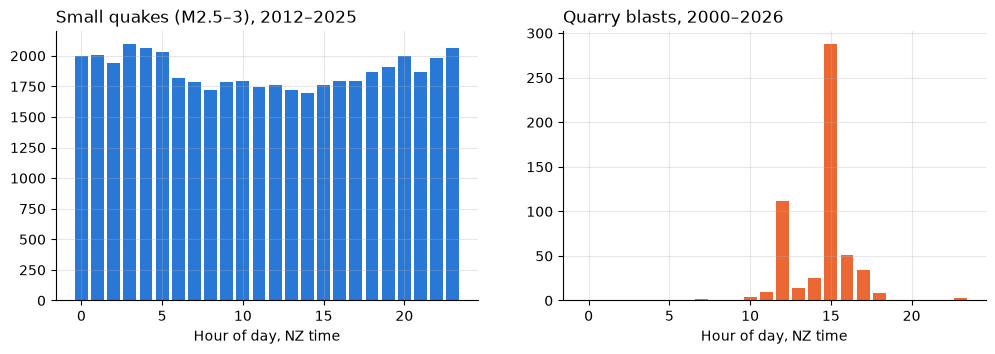

13% fewer small quakes detected 9am–5pm than overnight
72% of quarry blasts at noon or 3pm


In [16]:
h = q("SELECT * FROM hour_of_day")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.5))
a1.bar(h["hour"], h["small_quakes"], color=BLUE); a1.set_title("Small quakes (M2.5–3), 2012–2025", loc="left")
a2.bar(h["hour"], h["quarry_blasts"], color=ORANGE); a2.set_title("Quarry blasts, 2000–2026", loc="left")
for ax in (a1, a2): ax.set_xlabel("Hour of day, NZ time")
plt.show()
night = h.loc[(h["hour"] <= 4) | (h["hour"] >= 22), "small_quakes"].mean()
day = h.loc[h["hour"].between(9, 17), "small_quakes"].mean()
print(f"{1 - day / night:.0%} fewer small quakes detected 9am–5pm than overnight")
print(f"{h.loc[h['hour'].isin([12, 15]), 'quarry_blasts'].sum() / h['quarry_blasts'].sum():.0%} of quarry blasts at noon or 3pm")

Earthquakes don't keep office hours, so the daytime dip is a detection effect: traffic and machinery raise the noise floor and hide the faintest quakes. It matters for anything built on the smallest events, and is another reason to work above M3.

## 8. What's normal near each city

In [17]:
cities = pd.DataFrame(city_table(mod.drop(columns="is_main"), mod["is_main"].to_numpy()))
cities[["city", "m4_main", "m4_all", "m5_main", "m4_per_year", "every_years"]]

,city,m4_main,m4_all,m5_main,m4_per_year,every_years
0,Palmerston North,64,175,8,4.6,1.8
1,Napier,46,95,5,3.3,2.8
2,Gisborne,45,67,6,3.2,2.3
3,Wellington,41,513,6,2.9,2.3
4,Christchurch,41,156,5,2.9,2.8
5,Blenheim,33,651,6,2.4,2.3
6,Nelson,22,431,6,1.6,2.3
7,Queenstown,20,68,5,1.4,2.8
8,New Plymouth,11,23,2,0.8,7.0
9,Rotorua,10,31,4,0.7,3.5


Shallow (< 40 km) quakes within 100 km, 2012–2025. Counting mainshocks stops one sequence dominating: Blenheim, Wellington and Nelson have hundreds of M4+ quakes in total, mostly from the 2013 Cook Strait and 2016 Kaikōura sequences. These are observed rates over 14 years, not a hazard forecast.

## 9. Conclusions and limitations

1. **Three in four M3+ quakes are aftershocks.** Without them, New Zealand's background rate is steady at 400–500 M3+ mainshocks a year.
2. **Each step up in magnitude is about 7.6 times rarer** (b = 0.88). The country averages about 26 M5+ and two M6+ quakes a year.
3. **Aftershock sequences differ.** Kaikōura decayed faster (p = 1.31) than Darfield (p = 1.01).
4. **The plate boundary is visible in the data.** The Pacific plate can be traced to more than 200 km deep west of Taupō.
5. **The catalogue needs care.** A 2012 change in how magnitudes are calculated halves M3+ counts, small-quake detection drops by day, and the catalogue includes blasts, landslides and distant events.

**Limitations.** Magnitudes before 2012 aren't comparable with later ones below about M5, so rates use 2012–2025 only. Declustering windows are a convention, not ground truth. Aftershock boxes are drawn by hand around each rupture. City rates are 14 years of observations and say nothing about rare large quakes; GNS Science's National Seismic Hazard Model is the authority on hazard.